In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

from tqdm.notebook import tqdm
from torch.utils.data import DataLoader

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Вычисления будут идти на: {device}")

Вычисления будут идти на: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 🏗️ 1. Создание модели, оптимизатора и шедулера

In [5]:
class Model_PINN(nn.Module):
    def __init__(self, input=2, output=2, hidden_size=64, act="tanh", count_layers=4):
      super().__init__()
      self.dict_act = {"tanh": nn.Tanh, "gelu":nn.GELU, "silu": nn.SiLU}
      self.layers = nn.ModuleList()
      for i in range(count_layers):
        self.layers.add_module(f"layer_{i}", nn.Linear(input, hidden_size))
        self.layers.add_module(f"act_{i}", self.dict_act[act]())

        input = hidden_size
      self.layers.add_module(f"layer{count_layers}", nn.Linear(input, output))

    def forward(self, x):
      for i, layer in enumerate(self.layers):
        x = layer(x)
      out = x
      return out

In [6]:
activation_func = "silu"

In [7]:
model = Model_PINN(act=activation_func).to(device)

In [15]:
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                         mode="min",
                                                         factor=0.1,
                                                         patience=2500,)

---
## 📊 2. Подготовка обучающих данных

In [10]:
SIZE_DATA = 1000
SIZE_BATCH = 10000
EPOCHS = 50000
BORDER = 5
WEIGHT = 100

In [11]:
t = torch.rand(SIZE_DATA, 1, requires_grad=True).to(device) * 0.1
x = torch.rand(SIZE_DATA, 1, requires_grad=True).to(device) * BORDER*2 - BORDER


In [18]:
data_train_ph = DataLoader(torch.cat((x, t), dim=1), batch_size=SIZE_BATCH, shuffle=True)

--------
## 🔄 3. Цикл обучения


In [19]:
epoch_loop = tqdm(range(EPOCHS), leave=False)
treshold = 0.01
best_loss = None

for epoch in epoch_loop:
  mean_loss_list = []

  for batch in data_train_ph:
    opt.zero_grad()

    t = batch[:, 1:].detach().requires_grad_(True)
    x = batch[:, 0:1].detach().requires_grad_(True)
    x_left = torch.full_like(x, -BORDER).to(device).requires_grad_(True)
    x_right = torch.full_like(x, BORDER).to(device).requires_grad_(True)
    input = torch.cat((x, t), dim=1)

    u, v = torch.split(model(input), 1, dim=1)
    u_dt = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    v_dt = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]

    u_dx = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_dxx = torch.autograd.grad(u_dx, x, torch.ones_like(u_dx), create_graph=True)[0]
    v_dx = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_dxx = torch.autograd.grad(v_dx, x, torch.ones_like(v_dx), create_graph=True)[0]

    loss_ph_real = torch.mean((-v_dt + 0.5*(u_dxx) + (u**2 + v**2)*u) **2)

    loss_ph_imaginary = torch.mean((u_dt + 0.5*(v_dxx) + (u**2 + v**2)*v) **2)


    input_left = torch.cat((x_left, t), dim=1)
    input_right = torch.cat((x_right, t), dim=1)

    u_left, v_left = torch.split(model(input_left), 1, dim=1)
    u_right, v_right = torch.split(model(input_right), 1, dim=1)
    loss_start = torch.mean((u_left - u_right)**2 + (v_left - v_right)**2)

    u_left_dx = torch.autograd.grad(u_left, x_left, torch.ones_like(u_left), create_graph=True)[0]
    u_right_dx = torch.autograd.grad(u_right, x_right, torch.ones_like(u_right), create_graph=True)[0]
    v_left_dx = torch.autograd.grad(v_left, x_left, torch.ones_like(v_left), create_graph=True)[0]
    v_right_dx = torch.autograd.grad(v_right, x_right, torch.ones_like(v_right), create_graph=True)[0]
    loss_start_dx = torch.mean((u_left_dx - u_right_dx)**2 + (v_left_dx - v_right_dx)**2)

    t_0 = torch.zeros_like(x).to(device).requires_grad_(True)
    u_pred, v_pred = torch.split(model(torch.cat((x, t_0), dim=1)), 1, dim=1)

    u_start = 1.0 / torch.cosh(x)
    v_start = torch.zeros_like(x)

    loss_ic = torch.mean((u_pred - u_start)**2 + (v_pred - v_start)**2)

    loss_all = loss_ph_real + loss_ph_imaginary + WEIGHT*(loss_start + loss_start_dx + loss_ic)
    mean_loss_list.append(loss_all.item())
    loss_all.backward()
    opt.step()

  mean_loss = sum(mean_loss_list)/len(mean_loss_list)
  lr_scheduler.step(mean_loss)
  epoch_loop.set_description(f"Функция потерь:{mean_loss}")

  if best_loss is None:
    best_loss = mean_loss
  if mean_loss < (best_loss - best_loss * treshold):
    best_loss = mean_loss

    save_dict = {"state_dict": model.state_dict(),
                "state_shedduler": lr_scheduler.state_dict(),
                "epoch_step": epoch,
                "best_loss": best_loss,
                "func_activation": activation_func}

    torch.save(save_dict, "drive/MyDrive/save/NLSE_tanh.pth")
    if epoch % 100 == 0:
      print(f"На эпохе {epoch+1} сохранена модель со значение mean_loss {best_loss}")

  if(epoch % 5000 == 0):
    print(f"Значение функции потерь: {mean_loss} ; на эпохе {epoch + 1}, шаг обучения: {lr_scheduler.get_last_lr()}")


  0%|          | 0/50000 [00:00<?, ?it/s]

Значение функции потерь: 26.380128860473633 ; на эпохе 1, шаг обучения: [0.001]
На эпохе 101 сохранена модель со значение mean_loss 0.2837744653224945
На эпохе 201 сохранена модель со значение mean_loss 0.07421499490737915
На эпохе 501 сохранена модель со значение mean_loss 0.023275746032595634
На эпохе 601 сохранена модель со значение mean_loss 0.014441551640629768
На эпохе 3101 сохранена модель со значение mean_loss 0.0033474864903837442
На эпохе 3801 сохранена модель со значение mean_loss 0.0011763246729969978
Значение функции потерь: 0.00045591394882649183 ; на эпохе 5001, шаг обучения: [0.001]
Значение функции потерь: 0.00018841662677004933 ; на эпохе 10001, шаг обучения: [0.001]
Значение функции потерь: 0.00035710452357307076 ; на эпохе 15001, шаг обучения: [0.001]
Значение функции потерь: 0.0008539906702935696 ; на эпохе 20001, шаг обучения: [0.001]
Значение функции потерь: 8.035161590669304e-05 ; на эпохе 25001, шаг обучения: [0.001]
Значение функции потерь: 8.672528201714158e-

In [8]:
state_dict = torch.load("drive/MyDrive/save/NLSE_tanh.pth",map_location=device)
model.load_state_dict(state_dict["state_dict"])
print(state_dict["best_loss"], state_dict["epoch_step"])

2.0164290617685765e-05 49929


---
## 📈 4. Визуализация и проверка результатов


In [12]:
x_plot = torch.linspace(-BORDER, BORDER, 100).to(device)
t_plot = torch.linspace(0, 0.1, 100).to(device)
x_mesh, t_mesh = torch.meshgrid(x_plot, t_plot)
x_mesh = x_mesh.reshape(-1, 1)
t_mesh = t_mesh.reshape(-1, 1)

data = torch.cat((x_mesh, t_mesh), dim=1)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [13]:
data.shape

torch.Size([10000, 2])

In [14]:
with torch.no_grad():
  u, v = torch.split(model(data), 1, dim=1)

intensity = (u**2 + v**2).cpu().numpy()

In [15]:
Z = intensity.reshape(100, 100)

x_plot = x_plot.cpu().numpy()
t_plot = t_plot.cpu().numpy()
X_grid, T_grid = np.meshgrid(x_plot, t_plot)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3751/1795662688.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax.set_zlabel('Интенсивность $|\psi|^2$')


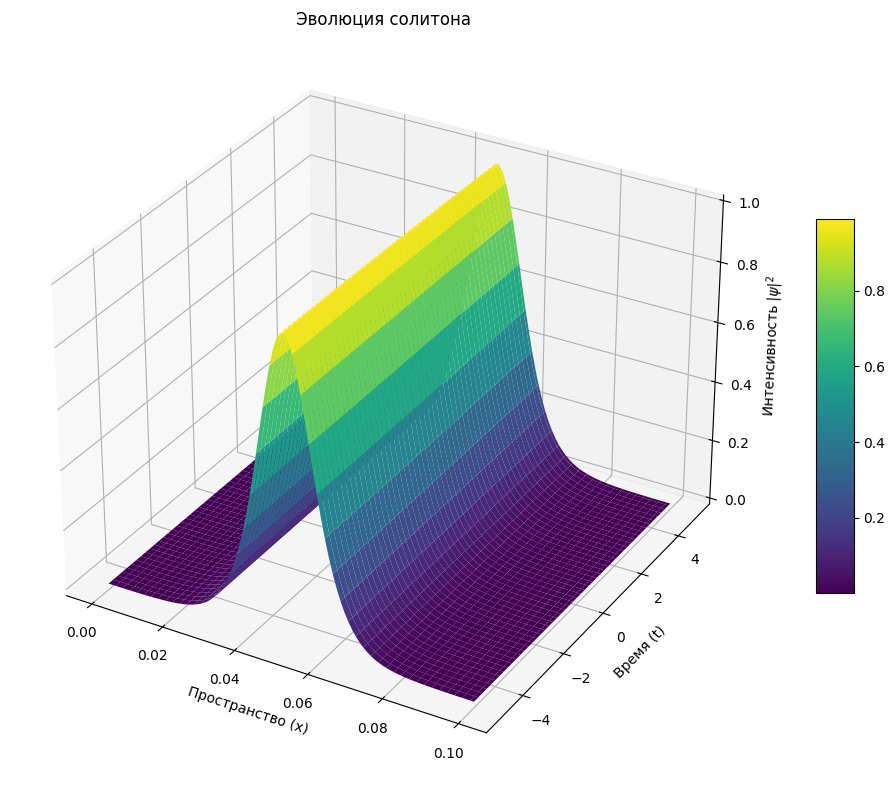

In [16]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid, X_grid, Z,
                       cmap='viridis',
                       edgecolor='none',
                       antialiased=True)

ax.set_xlabel('Пространство (x)')
ax.set_ylabel('Время (t)')
ax.set_zlabel('Интенсивность $|\psi|^2$')
ax.set_title('Эволюция солитона')

fig.colorbar(surf, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()